#  Réalisez une étude de santé publique avec R ou Python

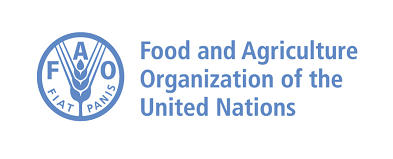

FAO est un des organes qui composent l’ONU et dont l’objectif est « d’aider à construire un monde libéré de la faim ». 

## Identification de besoins 

Les Informations demandées sont les données sur l'année 2017

- la proportion de personnes en état de sous-nutrition
- le nombre théorique de personnes qui pourraient être nourries avec la disponibilité alimentaire mondiale et des produits végétaux
- Utilisation de la disponibilité extérieure
- Proportion des pays où les personnes sous-alimentées est plus forte en 2017

##  Proposition fonctionnelle technique 

Pour la réalisation de ce projet j'ai choisi la programmation en <u>Python sous Jupyter Notebook</u>

- Manipulation des DataFrames 
- Créer un environnement de développement 
- Utiliser des librairies spécialisées pour les traitements data

## Importation des différents packages 

In [1]:
## Importation de librairies 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importation des différents fichiers et description de données

Nous avons 4 fichiers de données
- Un fichier <u>Disponibilité alimentaire</u> qui contient 17 variables
- Un fichier <u>population</u> avec 3 variables
- Un fichier <u>Aide Alimentaire</u> avec 4 variables
- Un fichier <u>sous-nitrution</u> avec 3 variables

### Analyse et découverte de données 

In [3]:
%cd C:\Users\user\Desktop\PROJET_4\DAN-P4-FAO

[WinError 3] Le chemin d’accès spécifié est introuvable: 'C:\\Users\\user\\Desktop\\PROJET_4\\DAN-P4-FAO'
C:\Users\thier\Desktop\OPENCLASSROOM\PROJET_4\Livrables


### Découverte de données : <u>Disposition alimentaire</u>

In [3]:
## importation de données disposition alimentaire en utilisant la fonction read_csv() de pandas 

Dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

In [4]:
## la fonction head() de pandas pour affichier les 5 premières lignes 
Dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


On constate qu'il y'a des valeurs de Nan dans le fichier, nous allons les remplacer avec la méthode fillna

In [5]:
# Avec la méthode Fillna, on remplace les valeurs Nan par par une autre valeur, ici on remplace par 0

Dispo_alimentaire.fillna(0, inplace=True)

#### Découverte de données de la <u>population</u>

In [6]:
## importation de données population en utilisant la fonction read_csv() de pandas

pop_FAO = pd.read_csv('population.csv')
pop_FAO.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


Dans le Lexique, on précise que la population est exprimé en millier d'habitants, nous allons multiplier par 1000. Changer le nom de la colonne Valeur par Population

In [7]:
pop_FAO['Valeur'] *= 1000

# Pour renommer le nom d'une variable par un nouveau nom, on utilise la fonction df.rename()
pop_FAO.rename(columns={"Valeur": "Population"}, inplace=True)
pop_FAO.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


#### Découverte des données de <u>l'aide Alimentaire</u>

In [8]:
# importation de données aide alimentaire en utilisant la fonction read_csv() de pandas

aid_alimentaire = pd.read_csv('aide_alimentaire.csv')
aid_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


Pour simplifier les calculs, on va renommer la colonne "Pays bénéficiaire" par "zone" comme dans les autres fichiers et remplacer "Valeur" par "Aid_aliment_kg". par la suite on multipliera par 1000 afin d'avoir les valeurs en kg.

In [9]:
# Renommer "Pays Bénéficiaire" par "aid_alimentaire"

aid_alimentaire.rename(columns={"Pays bénéficiaire": "Zone", "Valeur":"Aid_aliment_kg"}, inplace=True)
aid_alimentaire['Aid_aliment_kg'] *= 1000

#### Decouverte des données : <u>sous-nutrition</u>

In [10]:
# importation de données sous-nutrition en utilisant la fonction read_csv() de pandas

sous_nutri = pd.read_csv('sous_nutrition.csv')
sous_nutri.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [11]:
# Aperçu rapide du df
sous_nutri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB


In [12]:
# Affichage des valeurs unique de la colonne Valeur / on voit qu'on a un caractère "<"
sous_nutri.Valeur.unique()

array(['8.6', '8.8', '8.9', '9.7', '10.5', '11.1', '2.2', '2.5', '2.8',
       '3', '3.1', '3.3', '0.1', '1.3', '1.2', nan, '7.6', '6.2', '5.3',
       '5.6', '5.8', '5.7', '1.5', '1.6', '1.1', '1.7', '<0.1', '21.7',
       '22.4', '23.3', '22.3', '21.5', '20.9', '0.8', '2', '1.9', '1.8',
       '0.4', '0.5', '0.3', '0.2', '3.2', '3.4', '3.6', '3.8', '2.1',
       '2.3', '2.4', '0.6', '0.7', '0.9', '3.9', '2.7', '1.4', '4.8',
       '4.6', '4.9', '5', '4.4', '4.3', '4.2', '4.5', '26.2', '24.3',
       '21.3', '21.1', '2.9', '5.1', '5.2', '5.4', '203.8', '198.3',
       '193.1', '190.9', '190.1', '189.2', '23.6', '24', '24.1', '3.7',
       '7.3', '7.8', '8.4', '9', '9.1', '10.1', '10', '10.7', '11.5',
       '11.9', '11.8', '8.7', '10.3', '11', '1', '5.5', '6.8', '7.9',
       '5.9', '7', '9.2', '9.4', '9.6', '6.7', '7.1', '7.2', '14.7',
       '17.4', '20.2', '22.2', '22.8', '24.6', '31.1', '28.5', '25.4',
       '24.8', '26.1', '14.5', '15.4', '16.5', '15.8', '15.7', '10.8',
       '

On remarque des valeurs avec une approximation '<0.1', je vais remplacer l'approximation par 0.

Afin que la colonne "Valeur" soit plus parlant, nous allons la remplacer par "Sous_nutrition"

Dans le lexique, le nombre de personnes en sous-alimentation est exprimé en en million d'habitants, on va multiplier les valeurs par 1 000 000 pour avoir en habitant

In [13]:
# Changer un argument en un type numérique
sous_nutri['Valeur'] = pd.to_numeric(sous_nutri['Valeur'], errors='coerce')

# Remplacer '<0.1' par 0
sous_nutri.fillna(0, inplace=True)

# On va renommer "Valeur" par "sous_nutrition"
sous_nutri.rename(columns={"Valeur": "sous_nutrition"}, inplace=True)
sous_nutri['sous_nutrition'] *= 1000000

In [14]:
# Vérification des valeurs uniques de la variable "année" dans la table sous-nutrition

sous_nutri['Année'].unique()

array(['2012-2014', '2013-2015', '2014-2016', '2015-2017', '2016-2018',
       '2017-2019'], dtype=object)

## <u>Charge de travail demandée par Marc</u>

#### <u>1. Proportion de personnes en sous-nitrution pour l'année 2017</u>
Pour connaitre la proportion de personnes en etat de sous nitrution, une jointure entre les fichiers population et sous nitrution permettra de calculer le ratio

In [15]:
# Jointure entre la table "sous-nutrition" et "population" et ensuite filtrer sur l'année 2017
prop_sous_nutri = pd.merge(pop_FAO.loc[pop_FAO['Année'] == 2017,["Zone", "Population"]],
                               sous_nutri.loc[sous_nutri['Année'] == '2016-2018',["Zone", "sous_nutrition"]],
                               on='Zone')
prop_sous_nutri.head()

,Zone,Population,sous_nutrition
0,Afghanistan,36296113.0,10500000.0
1,Afrique du Sud,57009756.0,3100000.0
2,Albanie,2884169.0,100000.0
3,Algérie,41389189.0,1300000.0
4,Allemagne,82658409.0,0.0


In [16]:
# Affichage du résultat sur la proportion des personnes en état de sous-nutrition

print("Proportion de personnes en état de sous nutrition :", "{:.1f}".format(prop_sous_nutri['sous_nutrition'].sum()*100/
prop_sous_nutri['Population'].sum()), "%")

Proportion de personnes en état de sous nutrition : 7.1 %


#### <u>2. Le nombre théorique de personnes qui pourraient être nourries</u>
Dans la demande de Marc, cet calcul se fait à partir de la disponibilité alimentaire mondiale<br>
Nous allons multiplier par 1 000 000 toutes les colonnes dont l'unité est milliers de tonnes pour homogéneiser en kg

In [17]:
colonnes_tonnes_tokg = ['Aliments pour animaux', 'Disponibilité intérieure', 'Exportations - Quantité',
                        'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
                        'Semences', 'Traitement', 'Variation de stock', 'Autres Utilisations']

for elt in colonnes_tonnes_tokg:
    Dispo_alimentaire[elt] *= 1000000

Les disponibilités alimentaires sont exprimées en kcal/pers/j (ou g prot/pers/j), je vais merger avec la table population au niveau des pays, et multiplier cette colonne par la population et par 365 pour obtenir le total en kcal (ou g prot).

In [18]:
# Jointure interne entre le df Dispo_alimentaire et le df pop_FAO sur la colonne Zone
Dispo_alimentaire = Dispo_alimentaire.merge(pop_FAO.loc[pop_FAO['Année'] == 2017,["Zone", "Population"]],
                                            on='Zone')

# Calcul de la disponibilités alimentaire totale
Dispo_alimentaire['dispo_kcal'] = Dispo_alimentaire['Disponibilité alimentaire (Kcal/personne/jour)'] * Dispo_alimentaire['Population'] * 365
print("dispo alimentaire totale en kcal :", Dispo_alimentaire['dispo_kcal'].sum(), "kcal")

dispo alimentaire totale en kcal : 7635429388975815.0 kcal


Après des recherches sur Internet, les besoins en calories journaliers pour un être humain est compris 
<br> - entre 1800 et 2700 Kcal/j 
<br> - entre 80 et 95 g prot/j pour les besoins en proteines.
<br>Pour le calcul, je choisis 2500 comme moyenne pour cet exemple

In [23]:
# Pour afficher le total de personnes poouvant être nourris, je vais utiliser la fonction Round()
# afin d'arrondir les décimales

tot_h_kcal = round(Dispo_alimentaire['dispo_kcal'].sum()/(2500*365))

print("Total de personnes pouvant être nourris :", tot_h_kcal)
print("Proportion :", "{:.1f}".format(tot_h_kcal*100/pop_FAO.loc[pop_FAO['Année'] == 2017,"Population"].sum()), "%")

Total de personnes pouvant être nourris : 8367593851
Proportion : 110.9 %


#### <U>3. Idem pour les végétaux</u>

In [24]:
vegetaux = Dispo_alimentaire.loc[Dispo_alimentaire['Origine'] == "vegetale",:]

print("dispo alimentaire totale en kcal des produits végétaux :", vegetaux['dispo_kcal'].sum(), "kcal")
tot_h_kcal = round(vegetaux['dispo_kcal'].sum()/(2500*365))
print("Total de personnes pouvant être nourris :", tot_h_kcal)
print("Proportion :", "{:.1f}".format(tot_h_kcal*100/pop_FAO.loc[pop_FAO['Année'] == 2017,"Population"].sum()), "%")

dispo alimentaire totale en kcal des produits végétaux : 6300178937197865.0 kcal
Total de personnes pouvant être nourris : 6904305685
Proportion : 91.5 %


#### <u>4. Disponibilité Interieure</u>
l’utilisation de la disponibilité intérieure, en particulier la part qui est attribuée à <u>l’alimentation animale</u>, celle qui est <u>perdue</u> et celle qui est concrètement utilisée pour <u>l'alimentation humaine</u>

In [19]:
dispo_interieur = Dispo_alimentaire['Disponibilité intérieure'].sum()

# Je vais utiliser la fonction for pour les proportions car nous sommes dans une boucle bornée

for dpInt in ['Aliments pour animaux', 'Pertes', 'Nourriture']:
    print("Proportion de", dpInt, ":", "{:.1f}".format(Dispo_alimentaire[dpInt].sum()*100/dispo_interieur), "%")

Proportion de Aliments pour animaux : 13.2 %
Proportion de Pertes : 4.6 %
Proportion de Nourriture : 49.4 %


### <u>Les informations fournies par Julien</u>

Selon le lexique laissé par Julien :
Lors de ses recherches, il a découvert des chiffres intéressants sur l’utilisation des céréales, notamment la répartition entre <u>l’alimentation humaine</u> (colonne Nourriture) et <u>l’alimentation pour animaux</u>. La liste des céréales peut être trouvée en allant fouiller un peu dans l’onglet Bilans alimentaires.

Après, des recherches via le lien fourni par Julien dans le lexique, on obtient une liste des céréales sur la colonne produit :
- Avoine
- Blé et produit
- Céréales, autres
- Maïs et produits
- Millet et produits
- Orge et produits
- Riz et produits
- Seigle et produits
- Sorgho et produits

<u>Nous allons calculer:</u>
- La proportion d'alimentation animale
- La proportion d'alimentation humaine

In [20]:
cereales_list = ["Blé et produits", "Riz et produits", "Orge et produits", "Maïs et produits", "Seigle et produits",
                  "Avoine", "Millet et produits", "Sorgho et produits", "Céréales, Autres"]

#Création d'une table ne contenant que les informations des céréales
cereales = Dispo_alimentaire.loc[Dispo_alimentaire['Produit'].isin(cereales_list),:] 

print("Proportion d'alimentation animale :", "{:.1f}".format(cereales['Aliments pour animaux'].sum()*100/cereales['Disponibilité intérieure'].sum()), "%")
print("Proportion d'alimentation humaine :", "{:.1f}".format(cereales['Nourriture'].sum()*100/cereales['Disponibilité intérieure'].sum()), "%")

Proportion d'alimentation animale : 69.7 %
Proportion d'alimentation humaine : 17.6 %


- Le cas de la Thaïlande et du manioc

In [21]:
thai = prop_sous_nutri.loc[prop_sous_nutri['Zone'] == 'Thaïlande',:]
print('Proportion en sous nutrition en Thaïlande :', "{:.1f}".format(thai['sous_nutrition'].iloc[0]*100/thai['Population'].iloc[0]), "%")

Proportion en sous nutrition en Thaïlande : 9.0 %


In [22]:
# La proportion exportée doit être calculée à partir de la production
thai_manioc = Dispo_alimentaire.loc[(Dispo_alimentaire['Produit'] == "Manioc") & (Dispo_alimentaire['Zone'] == "Thaïlande"),:]
print('Proportion de manioc exportée :', "{:.1f}".format(thai_manioc['Exportations - Quantité'].iloc[0]*100 / 
                                                                     thai_manioc['Production'].iloc[0]), "%")

Proportion de manioc exportée : 83.4 %


### <u>Les besoins de Mélanie</u>

-  Pays pour lesquels la proportion de personnes sous-alimentées est la plus forte en 2017. (exemple sur 15 pays)

In [23]:
# Calcul de la proportion de personnes sous-alimentées sur la population

prop_sous_nutri['proportion'] = prop_sous_nutri['sous_nutrition']/prop_sous_nutri['Population']

# Affichage des proportions par pays trier et par ordre décroissant avec la fonction Sort_values et ascending

prop_sous_nutri[['Zone', "proportion"]].sort_values(by="proportion", ascending=False).head(15)

,Zone,proportion
78,Haïti,0.482592
157,République populaire démocratique de Corée,0.471887
108,Madagascar,0.410629
103,Libéria,0.382797
100,Lesotho,0.382494
183,Tchad,0.379576
161,Rwanda,0.350556
121,Mozambique,0.328109
186,Timor-Leste,0.321735
0,Afghanistan,0.289287


- Les pays qui ont le plus bénéficié aide depuis 2013. (exemple sur 15 pays)

In [24]:
# Pour afficher les pays qui ont le plus bénéficié de l'aide depuis 2013, nous allons utiliser la fonction groupby ()
# afin d'agréger efficacement les données 

Aide_2013 = aid_alimentaire[['Zone','Aid_aliment_kg']].groupby("Zone").sum()

Aide_2013.sort_values(by="Aid_aliment_kg", ascending=False).head(15)

,Aid_aliment_kg
Zone,
République arabe syrienne,1858943000
Éthiopie,1381294000
Yémen,1206484000
Soudan du Sud,695248000
Soudan,669784000
Kenya,552836000
Bangladesh,348188000
Somalie,292678000
République démocratique du Congo,288502000


- Les pays ayant le plus/le moins de disponibilité/habitant

In [25]:
# Pour connaître les pays ayant le moins de disponibilité / habitant, nous utiliserons la méthode Groupby()
#afin d'agréger efficacement les données

Tot_Dispo_Pays = Dispo_alimentaire[['Zone','Produit','Disponibilité alimentaire (Kcal/personne/jour)']].groupby('Zone').sum()

# Affichage des 15 pays trier par ordre croissant
Tot_Dispo_Pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)").head(15)

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
République centrafricaine,1879.0
Zambie,1924.0
Madagascar,2056.0
Afghanistan,2087.0
Haïti,2089.0
République populaire démocratique de Corée,2093.0
Tchad,2109.0
Zimbabwe,2113.0
Ouganda,2126.0
